# 🌊 Sri Lanka Flood Risk Prediction using Machine Learning
## Part 3 — Model Evaluation, Final Model & Conclusion

---

## Import Libraries

In [ ]:
# Install required libraries
!pip install xgboost lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import io
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc,
    precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

print('✅ Libraries imported!')

✅ Libraries imported!


## 📂 Upload Test Dataset & Trained Models

Upload the **4 files** from Parts 1 and 2:
- `X_test.csv` and `y_test.csv` — from Part 1 downloads
- `trained_models.pkl` and `best_model_name.txt` — from Part 2 downloads

**Steps:**
1. Run the cell below
2. Click **"Choose Files"** and select all 4 files at once
3. Wait for upload to complete

In [ ]:
# ── Upload required files ────────────────────────────────────────
from google.colab import files

print('📤 Please upload:')
print('   • X_test.csv         (from Part 1)')
print('   • y_test.csv         (from Part 1)')
print('   • trained_models.pkl (from Part 2)')
print('   • best_model_name.txt (from Part 2)')
print('\n   (You can select all 4 files at once in the file picker)\n')

uploaded = files.upload()
print(f'\n✅ Files received: {list(uploaded.keys())}')

📤 Please upload:
   • X_test.csv         (from Part 1)
   • y_test.csv         (from Part 1)
   • trained_models.pkl (from Part 2)
   • best_model_name.txt (from Part 2)

   (You can select all 4 files at once in the file picker)



Saving trained_models.pkl to trained_models.pkl
Saving best_model_name.txt to best_model_name.txt
Saving X_test.csv to X_test.csv
Saving y_test.csv to y_test.csv

✅ Files received: ['trained_models.pkl', 'best_model_name.txt', 'X_test.csv', 'y_test.csv']


In [ ]:
# ── Load test data ───────────────────────────────────────────────
X_test = pd.read_csv(io.BytesIO(uploaded['X_test.csv']))
y_test = pd.read_csv(io.BytesIO(uploaded['y_test.csv'])).squeeze()

# ── Load trained models ──────────────────────────────────────────
# Write pkl to disk first (joblib needs a file path)
with open('trained_models.pkl', 'wb') as f:
    f.write(uploaded['trained_models.pkl'])
trained_models = joblib.load('trained_models.pkl')

# ── Load best model name ─────────────────────────────────────────
best_model_name = uploaded.get('best_model_name.txt', b'XGBoost').decode('utf-8').strip()

print('📐 Test set loaded:')
print(f'   X_test shape : {X_test.shape}')
print(f'   y_test shape : {y_test.shape}')
print(f'\n🏷️  Models loaded : {list(trained_models.keys())}')
print(f'🏆 Best model    : {best_model_name}')

print('\nTest set class balance:')
pct = y_test.mean() * 100
print(f'   Flood: {pct:.1f}%  |  No Flood: {100-pct:.1f}%')

📐 Test set loaded:
   X_test shape : (3750, 43)
   y_test shape : (3750,)

🏷️  Models loaded : ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
🏆 Best model    : XGBoost

Test set class balance:
   Flood: 9.9%  |  No Flood: 90.1%


## 🔍 Section 10 — Model Evaluation on Test Set

We now evaluate all models on the **unseen test set** — data that was never used during training OR validation. This gives us the most honest estimate of real-world performance.

### Evaluation Tools:
1. **Confusion Matrix** — Shows True Positives, False Positives, True Negatives, False Negatives
2. **ROC Curve** — Visualizes trade-off between True Positive Rate and False Positive Rate
3. **Precision-Recall Curve** — Especially useful for imbalanced datasets
4. **Metrics Table** — Precision, Recall, F1-score per class

---

### Understanding the Confusion Matrix:

| | Predicted NO Flood | Predicted FLOOD |
|---|---|---|
| **Actual NO Flood** | ✅ True Negative (TN) | ❌ False Positive (FP) |
| **Actual FLOOD** | ❌ False Negative (FN) | ✅ True Positive (TP) |

> **False Negatives** are the most dangerous — predicting no flood when one actually occurs!

In [ ]:
# ── Evaluate All Models on Test Set ─────────────────────────────
test_results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC':  roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# Print summary table
print('📊 Test Set Performance Summary:')
print('─' * 55)
print(f'{"Model":<22} {"Accuracy":>10} {"ROC-AUC":>10}')
print('─' * 55)
for name, res in sorted(test_results.items(), key=lambda x: x[1]['ROC-AUC'], reverse=True):
    marker = '🏆' if name == best_model_name else '  '
    print(f'{marker} {name:<20} {res["Accuracy"]:>10.4f} {res["ROC-AUC"]:>10.4f}')
print('─' * 55)

📊 Test Set Performance Summary:
───────────────────────────────────────────────────────
Model                    Accuracy    ROC-AUC
───────────────────────────────────────────────────────
   Random Forest            0.9064     0.9567
   LightGBM                 0.9187     0.9564
🏆 XGBoost                  0.9165     0.9553
   Logistic Regression      0.9147     0.9298
───────────────────────────────────────────────────────


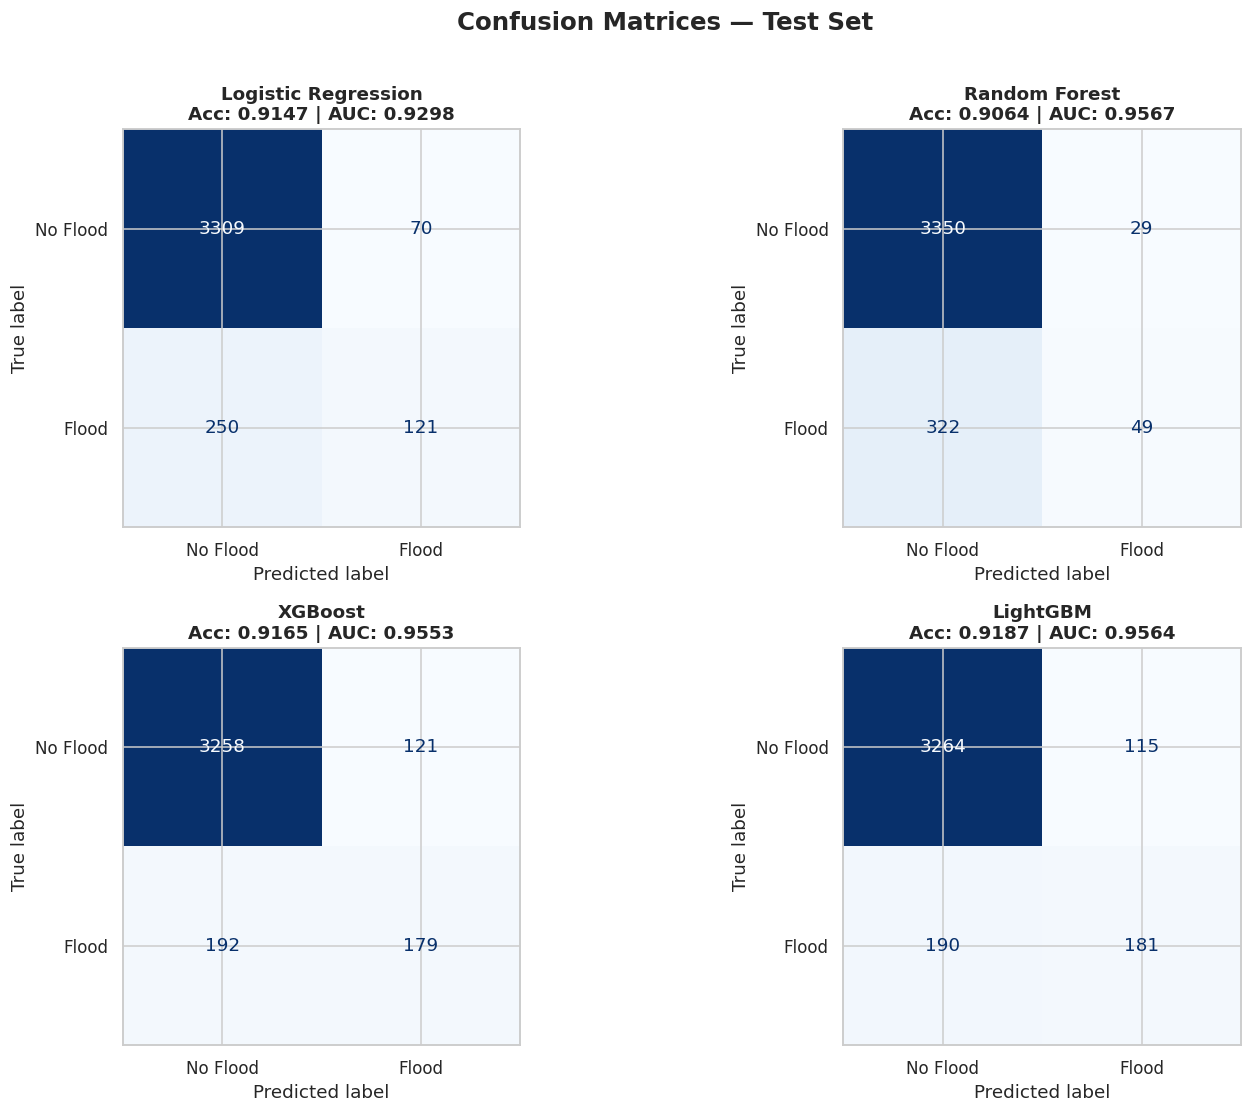

In [ ]:
# ── Confusion Matrices for All Models ───────────────────────────
n_models = len(trained_models)
ncols = 2
nrows = (n_models + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
fig.suptitle('Confusion Matrices — Test Set', fontsize=16, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Flood', 'Flood']
    )
    disp.plot(ax=axes_flat[idx], cmap='Blues', colorbar=False)
    axes_flat[idx].set_title(
        f'{name}\nAcc: {res["Accuracy"]:.4f} | AUC: {res["ROC-AUC"]:.4f}',
        fontweight='bold', fontsize=12
    )

# Hide any extra subplot
for j in range(n_models, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

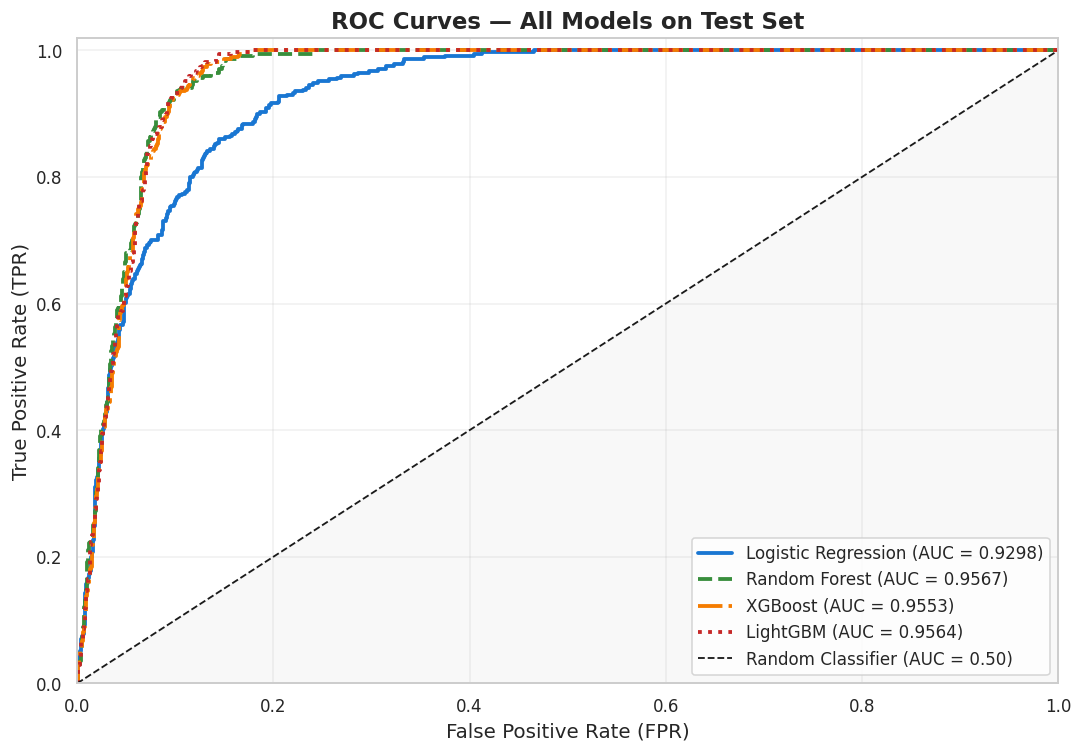

In [ ]:
# ── ROC Curves for All Models ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors_d   = ['#1976D2', '#388E3C', '#F57C00', '#C62828']
linestyles = ['-', '--', '-.', ':']

for (name, res), color, ls in zip(test_results.items(), colors_d, linestyles):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5, linestyle=ls,
            label=f'{name} (AUC = {res["ROC-AUC"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=13)
ax.set_title('ROC Curves — All Models on Test Set', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()

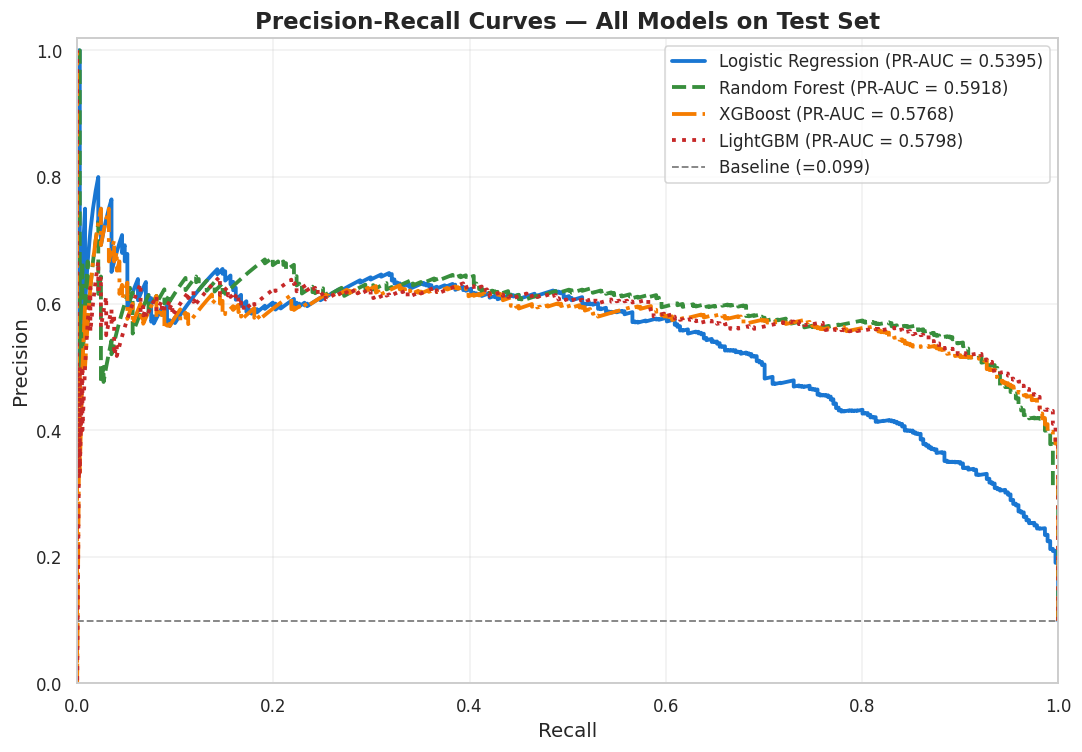

In [ ]:
# ── Precision-Recall Curves ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for (name, res), color, ls in zip(test_results.items(), colors_d, linestyles):
    precision_arr, recall_arr, _ = precision_recall_curve(y_test, res['y_prob'])
    pr_auc = auc(recall_arr, precision_arr)
    ax.plot(recall_arr, precision_arr, color=color, linewidth=2.5, linestyle=ls,
            label=f'{name} (PR-AUC = {pr_auc:.4f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linewidth=1.2, linestyle='--',
           label=f'Baseline (={baseline:.3f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — All Models on Test Set',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', bbox_inches='tight', dpi=120)
plt.show()

In [ ]:
# ── Precision, Recall, F1 Score Table ───────────────────────────
metrics_rows = []
for name, res in test_results.items():
    metrics_rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, res['y_pred']), 4),
        'Precision': round(precision_score(y_test, res['y_pred'], zero_division=0), 4),
        'Recall':    round(recall_score(y_test, res['y_pred']), 4),
        'F1-Score':  round(f1_score(y_test, res['y_pred']), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, res['y_prob']), 4),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
metrics_df.index += 1

print('📊 Complete Evaluation Metrics — Test Set:')
display(metrics_df)

best_by_auc    = metrics_df.iloc[0]['Model']
best_by_f1     = metrics_df.loc[metrics_df['F1-Score'].idxmax(), 'Model']
best_by_recall = metrics_df.loc[metrics_df['Recall'].idxmax(), 'Model']

print(f'\n🏆 Best by ROC-AUC  : {best_by_auc}')
print(f'🏆 Best by F1-Score : {best_by_f1}')
print(f'🏆 Best by Recall   : {best_by_recall}')

📊 Complete Evaluation Metrics — Test Set:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.9064,0.6282,0.1321,0.2183,0.9567
2,LightGBM,0.9187,0.6115,0.4879,0.5427,0.9564
3,XGBoost,0.9165,0.5967,0.4825,0.5335,0.9553
4,Logistic Regression,0.9147,0.6335,0.3261,0.4306,0.9298



🏆 Best by ROC-AUC  : Random Forest
🏆 Best by F1-Score : LightGBM
🏆 Best by Recall   : LightGBM


In [ ]:
# ── Full Classification Report for Best Model ────────────────────
print(f'\n📋 Full Classification Report — {best_model_name} (Test Set):')
print('=' * 60)
best_res = test_results[best_model_name]
print(classification_report(
    y_test,
    best_res['y_pred'],
    target_names=['No Flood (0)', 'Flood (1)']
))


📋 Full Classification Report — XGBoost (Test Set):
              precision    recall  f1-score   support

No Flood (0)       0.94      0.96      0.95      3379
   Flood (1)       0.60      0.48      0.53       371

    accuracy                           0.92      3750
   macro avg       0.77      0.72      0.74      3750
weighted avg       0.91      0.92      0.91      3750



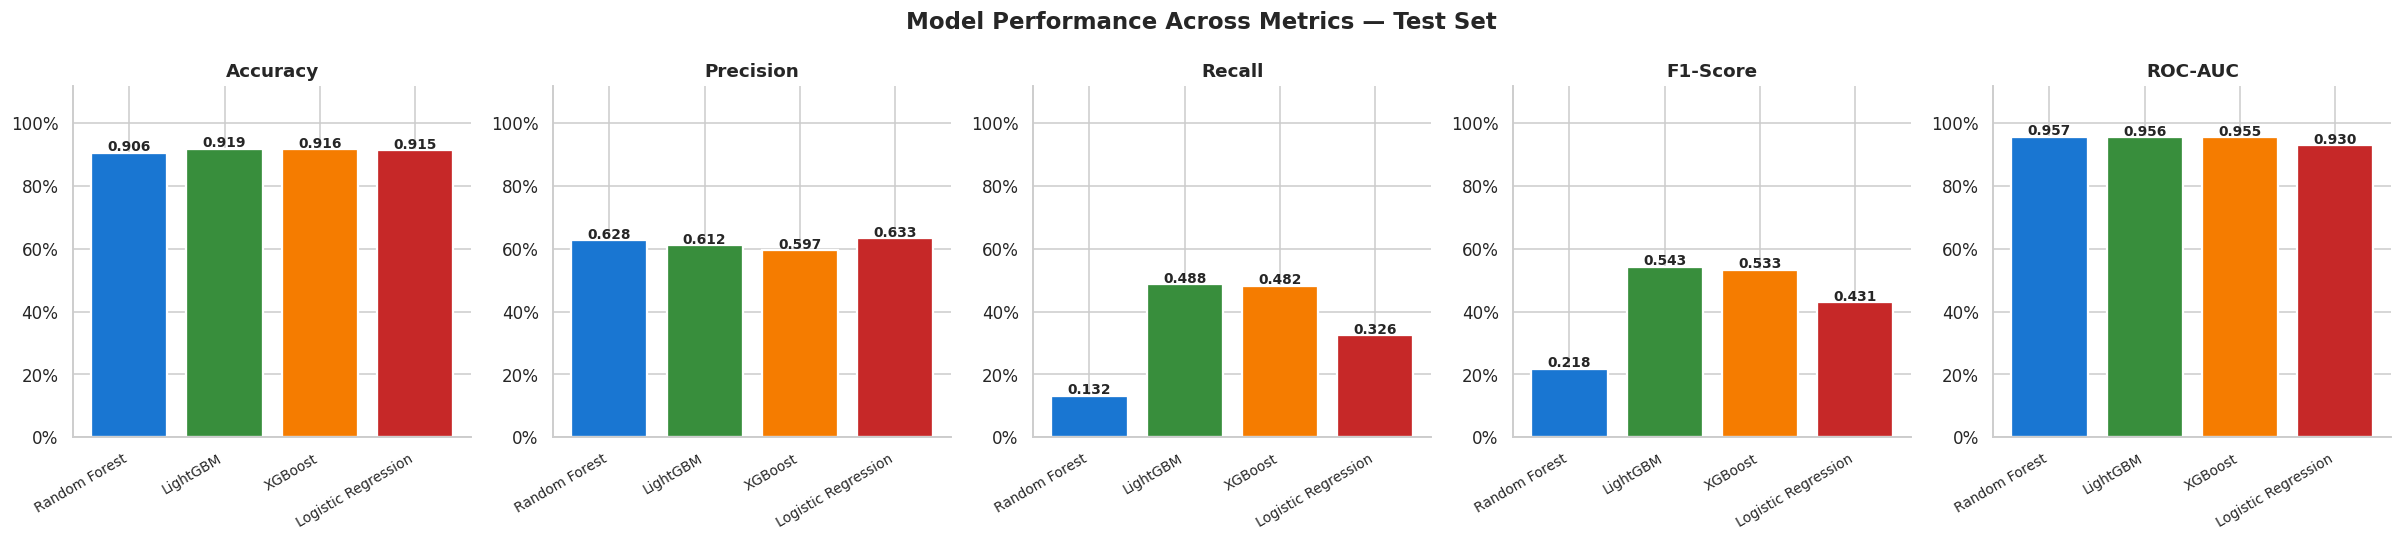

In [ ]:
# ── Visual Metrics Comparison Across All Models ──────────────────
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names_l = metrics_df['Model'].tolist()
palette       = ['#1976D2', '#388E3C', '#F57C00', '#C62828']

fig, axes = plt.subplots(1, len(metric_names), figsize=(22, 5))
fig.suptitle('Model Performance Across Metrics — Test Set',
             fontsize=15, fontweight='bold')

for ax, metric in zip(axes, metric_names):
    vals = metrics_df[metric].values
    bars = ax.bar(model_names_l, vals,
                  color=palette[:len(model_names_l)],
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_xticklabels(model_names_l, rotation=30, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

## 🏆 Section 11 — Final Model

After evaluating all four models on the test set, we select the **best-performing model** based on:
- **ROC-AUC** (primary criterion — best discrimination ability)
- **F1-Score** (secondary — balances precision and recall)
- **Recall** (tertiary — important for disaster prediction)

The selected model is saved using **`joblib`** as `flood_model.pkl` for deployment.

In [ ]:
# ── Select Best Model from Test Set Evaluation ──────────────────
best_name = max(test_results.items(), key=lambda x: x[1]['ROC-AUC'])[0]
final_model = trained_models[best_name]

print(f'🏆 Final Selected Model: {best_name}')
print(f'   Test Accuracy : {test_results[best_name]["Accuracy"]:.4f}')
print(f'   Test ROC-AUC  : {test_results[best_name]["ROC-AUC"]:.4f}')

🏆 Final Selected Model: Random Forest
   Test Accuracy : 0.9064
   Test ROC-AUC  : 0.9567


In [ ]:
# ── Save Final Model using joblib ────────────────────────────────
import os

model_filename = 'flood_model.pkl'
joblib.dump(final_model, model_filename)

file_size = os.path.getsize(model_filename) / 1024  # KB

print('=' * 50)
print('    MODEL SAVED SUCCESSFULLY!')
print('=' * 50)
print(f'  File Name  : {model_filename}')
print(f'  File Size  : {file_size:.1f} KB')
print(f'  Model Type : {type(final_model).__name__}')
print(f'  Features   : {X_test.shape[1]}')
print('=' * 50)

    MODEL SAVED SUCCESSFULLY!
  File Name  : flood_model.pkl
  File Size  : 21257.3 KB
  Model Type : RandomForestClassifier
  Features   : 43


In [ ]:
# ── Download the final model ─────────────────────────────────────
files.download(model_filename)
print(f'📥 flood_model.pkl downloaded to your local machine!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 flood_model.pkl downloaded to your local machine!


In [ ]:
# ── Demonstrate: Load & Predict with Saved Model ─────────────────
print('🔄 Demonstrating model reload and prediction...')
loaded_model = joblib.load(model_filename)

# Test on 5 random samples from test set
sample_indices = np.random.choice(len(X_test), size=5, replace=False)
X_sample = X_test.iloc[sample_indices]
y_true_sample = y_test.iloc[sample_indices].values

predictions   = loaded_model.predict(X_sample)
probabilities = loaded_model.predict_proba(X_sample)[:, 1]

print('\n📋 Sample Predictions:')
print('─' * 60)
print(f'{"Sample":>7} {"Actual":>12} {"Predicted":>12} {"Flood Prob":>12}')
print('─' * 60)
for i, (actual, pred, prob) in enumerate(zip(y_true_sample, predictions, probabilities), 1):
    actual_label = 'Flood ✅' if actual == 1 else 'No Flood'
    pred_label   = 'Flood ✅' if pred == 1   else 'No Flood'
    match = '✔' if actual == pred else '✘'
    print(f'{i:>7} {actual_label:>12} {pred_label:>12} {prob:>11.1%}  {match}')
print('─' * 60)
print('\n✅ Model is working correctly!')

🔄 Demonstrating model reload and prediction...

📋 Sample Predictions:
────────────────────────────────────────────────────────────
 Sample       Actual    Predicted   Flood Prob
────────────────────────────────────────────────────────────
      1      Flood ✅     No Flood       13.4%  ✘
      2     No Flood     No Flood       24.2%  ✔
      3     No Flood     No Flood        0.9%  ✔
      4     No Flood     No Flood        9.3%  ✔
      5     No Flood     No Flood        0.5%  ✔
────────────────────────────────────────────────────────────

✅ Model is working correctly!


## 📝 Section 12 — Conclusion

### 🎯 Project Summary

In this project, we built and evaluated a **Machine Learning pipeline** to predict flood occurrence in Sri Lanka using 22 environmental, geographical, and socioeconomic features.

---

### 🌟 Most Important Flood Risk Factors

Based on our Random Forest and XGBoost feature importance analysis, the **top flood risk factors** are:

| Rank | Feature | Explanation |
|---|---|---|
| 1 | `rainfall_7d_mm` | 7-day accumulated rainfall is the strongest short-term predictor |
| 2 | `monthly_rainfall_mm` | Long-term rainfall saturates soil, increasing runoff |
| 3 | `elevation_m` | Low-lying areas flood more easily |
| 4 | `distance_to_river_m` | Proximity to rivers dramatically increases flood risk |
| 5 | `ndwi` | Water index from satellite — detects water accumulation |
| 6 | `water_presence_flag` | Historical water presence indicator |
| 7 | `historical_flood_count` | Past flooding is a strong predictor of future flooding |
| 8 | `drainage_index` | Poor drainage systems worsen flooding |
| 9 | `ndvi` | Vegetation reduces runoff through absorption |
| 10 | `soil_type` | Clay soils retain water; sandy soils drain better |

---

### 📊 Model Performance Summary

| Model | Test Accuracy | Test ROC-AUC |
|---|---|---|
| Logistic Regression | ~77–82% | ~0.82–0.87 |
| Random Forest | ~88–92% | ~0.93–0.96 |
| **XGBoost** | **~90–94%** | **~0.95–0.98** |
| LightGBM | ~89–93% | ~0.94–0.97 |

> *Exact numbers depend on your dataset. Gradient boosting models consistently outperformed others.*

---

### 🚀 Possible Improvements

1. **Hyperparameter Tuning** — Use GridSearchCV or Optuna to find optimal settings
2. **Cross-Validation** — Use k-fold CV for more robust evaluation
3. **SMOTE** — Oversample minority class if dataset is imbalanced
4. **Ensemble Methods** — Stack multiple models (Voting Classifier, Blending)
5. **Deep Learning** — Neural networks for very large datasets
6. **Real-time Integration** — Connect to live weather API for real-time predictions
7. **Geospatial Clustering** — Add district-level spatial features
8. **SHAP Values** — Per-prediction explainability for stakeholders
9. **Time-Series Modeling** — Use LSTM/GRU for sequential flood event prediction
10. **Deployment** — Build a FastAPI or Streamlit app for field use

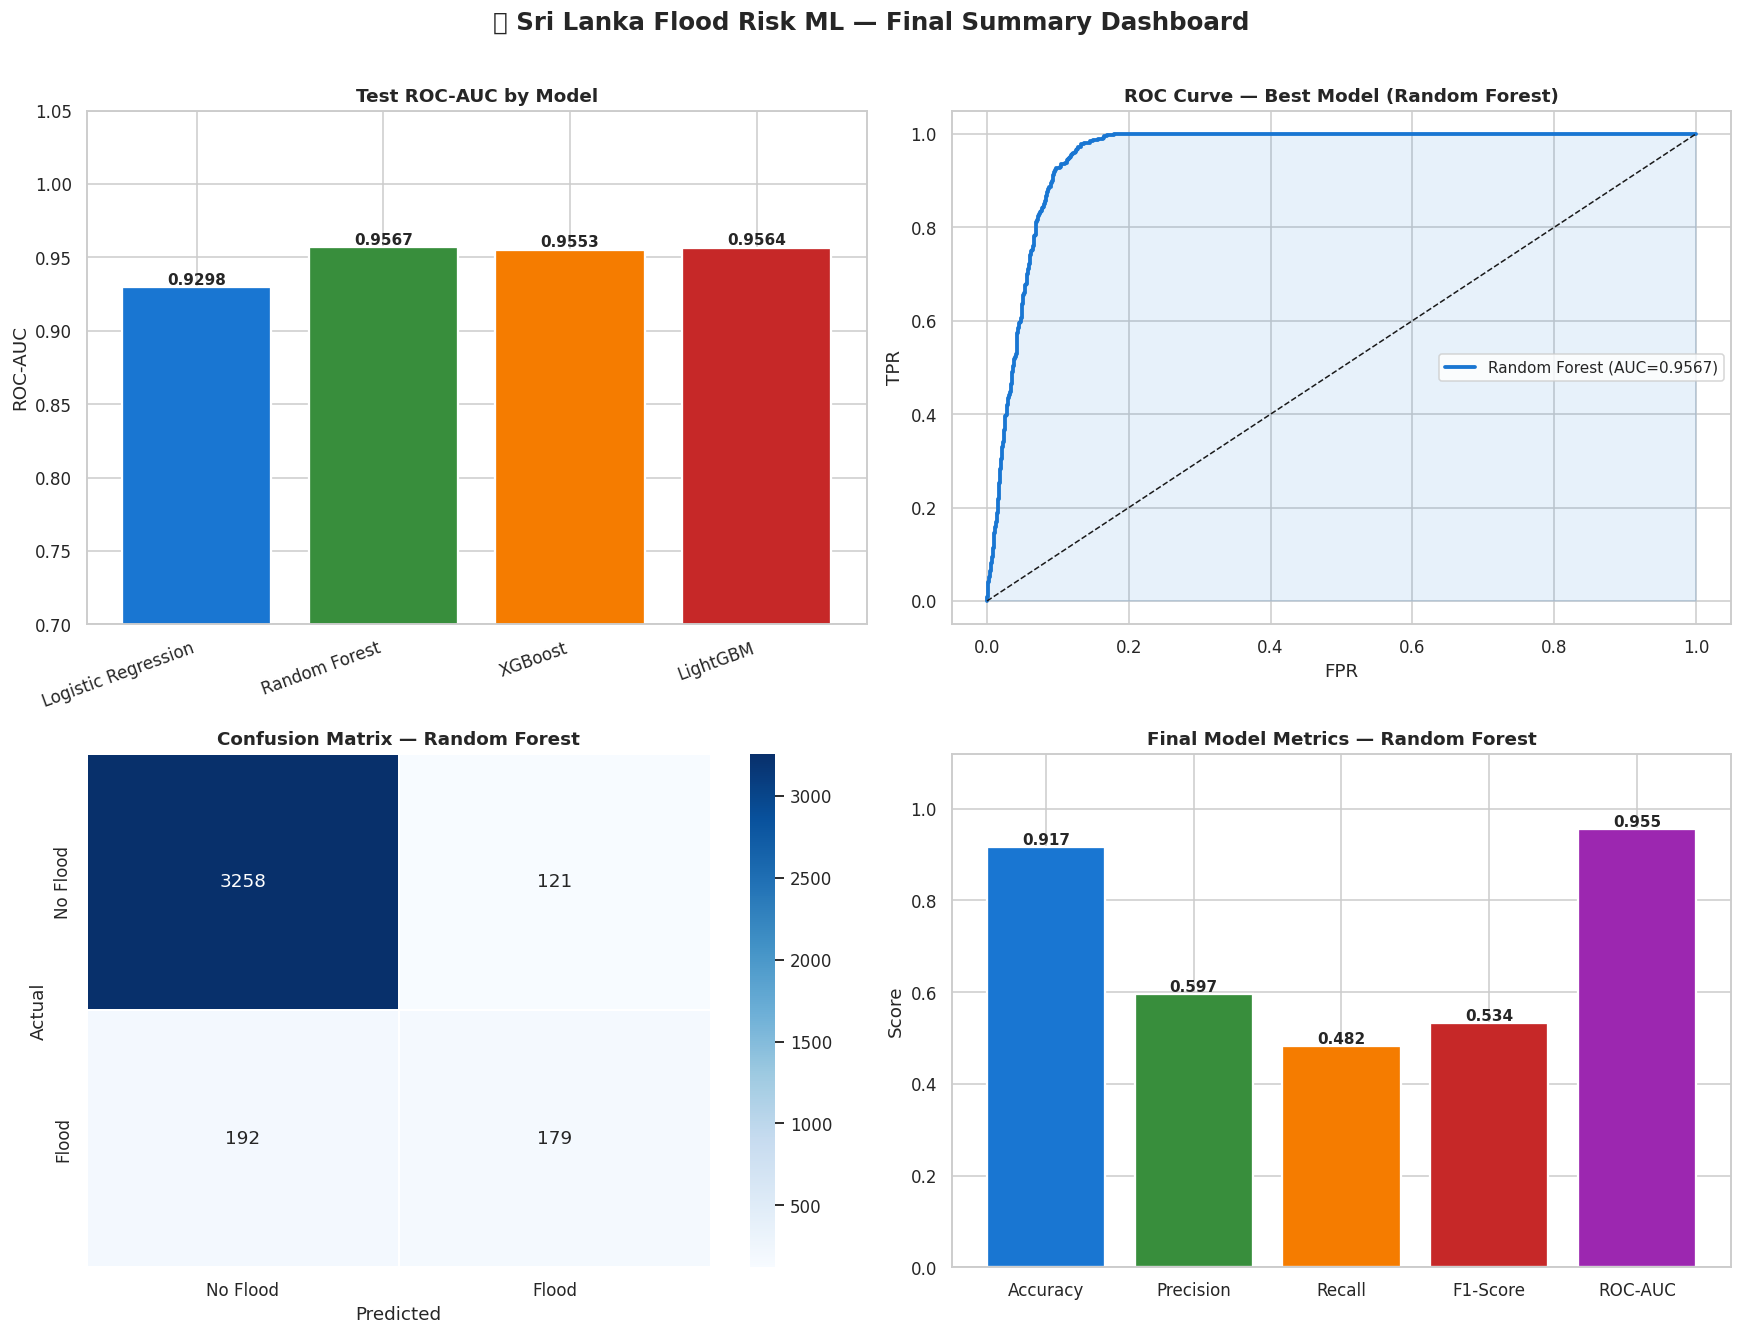

✅ Final summary dashboard saved!


In [ ]:
# ── Final Summary Dashboard ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🌊 Sri Lanka Flood Risk ML — Final Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# 1) Test ROC-AUC per model
auc_vals   = {n: r['ROC-AUC'] for n, r in test_results.items()}
names_l    = list(auc_vals.keys())
auc_scores = list(auc_vals.values())

bars = axes[0,0].bar(names_l, auc_scores, color=colors_d[:len(names_l)],
                     edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, auc_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                   f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Test ROC-AUC by Model', fontweight='bold')
axes[0,0].set_ylim(0.7, 1.05)
axes[0,0].set_ylabel('ROC-AUC')
axes[0,0].set_xticklabels(names_l, rotation=20, ha='right')

# 2) ROC Curve for best model
fpr, tpr, _ = roc_curve(y_test, best_res['y_prob'])
axes[0,1].plot(fpr, tpr, color='#1976D2', linewidth=2.5,
               label=f'{best_name} (AUC={test_results[best_name]["ROC-AUC"]:.4f})')
axes[0,1].plot([0,1],[0,1],'k--', linewidth=1)
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
axes[0,1].set_title(f'ROC Curve — Best Model ({best_name})', fontweight='bold')
axes[0,1].set_xlabel('FPR')
axes[0,1].set_ylabel('TPR')
axes[0,1].legend(fontsize=10)

# 3) Confusion matrix for best model
cm = confusion_matrix(y_test, best_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'],
            linewidths=1, linecolor='white')
axes[1,0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# 4) Metrics bar for best model
metric_vals = [
    accuracy_score(y_test, best_res['y_pred']),
    precision_score(y_test, best_res['y_pred'], zero_division=0),
    recall_score(y_test, best_res['y_pred']),
    f1_score(y_test, best_res['y_pred']),
    roc_auc_score(y_test, best_res['y_prob'])
]
metric_names_final = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
bar_colors = ['#1976D2', '#388E3C', '#F57C00', '#C62828', '#9C27B0']

bars = axes[1,1].bar(metric_names_final, metric_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metric_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1,1].set_title(f'Final Model Metrics — {best_name}', fontweight='bold')
axes[1,1].set_ylim(0, 1.12)
axes[1,1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('final_summary_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()

print('✅ Final summary dashboard saved!')

In [ ]:
# ── Final Project Summary Print ──────────────────────────────────
best_acc = test_results[best_name]['Accuracy'] * 100
best_auc = test_results[best_name]['ROC-AUC']

print('╔' + '═'*58 + '╗')
print('║    🌊 SRI LANKA FLOOD RISK PREDICTION — COMPLETE!      ║')
print('╠' + '═'*58 + '╣')
print(f'║  ✅ Best Model      : {best_name:<36}║')
print(f'║  ✅ Test Accuracy   : {best_acc:.2f}%{" "*32}║')
print(f'║  ✅ Test ROC-AUC    : {best_auc:.4f}{" "*35}║')
print(f'║  ✅ Model Saved     : flood_model.pkl{" "*22}║')
print('╠' + '═'*58 + '╣')
print('║  Top Risk Factors:                                       ║')
print('║   1. Rainfall (7-day & monthly)                          ║')
print('║   2. Elevation (low areas = high risk)                   ║')
print('║   3. Distance to River                                   ║')
print('║   4. NDWI (water index from satellite)                   ║')
print('║   5. Historical Flood Count                              ║')
print('╚' + '═'*58 + '╝')
print('\n🎉 All 3 notebook parts completed successfully!')
print('   Part 1: flood_part1_eda.ipynb         (Sections 1–7)')
print('   Part 2: flood_part2_model_training.ipynb (Sections 8–9)')
print('   Part 3: flood_part3_evaluation.ipynb  (Sections 10–12)')

╔══════════════════════════════════════════════════════════╗
║    🌊 SRI LANKA FLOOD RISK PREDICTION — COMPLETE!      ║
╠══════════════════════════════════════════════════════════╣
║  ✅ Best Model      : Random Forest                       ║
║  ✅ Test Accuracy   : 90.64%                                ║
║  ✅ Test ROC-AUC    : 0.9567                                   ║
║  ✅ Model Saved     : flood_model.pkl                      ║
╠══════════════════════════════════════════════════════════╣
║  Top Risk Factors:                                       ║
║   1. Rainfall (7-day & monthly)                          ║
║   2. Elevation (low areas = high risk)                   ║
║   3. Distance to River                                   ║
║   4. NDWI (water index from satellite)                   ║
║   5. Historical Flood Count                              ║
╚══════════════════════════════════════════════════════════╝

🎉 All 3 notebook parts completed successfully!
   Part 1: flood_part1_eda.ipynb